📥 Dataset Link

👉 Kaggle (CSV format):
https://www.kaggle.com/datasets/mohamedmoharam88/heart-disease-uci-dataset-csv


📌 What this dataset contains
Total records: ~300 patients
Features: 13+ medical attributes
Target: Heart disease presence

🔍 Important Features:
age → Age of patient
sex → Gender
cp → Chest pain type
trestbps → Blood pressure
chol → Cholesterol level
thalach → Maximum heart rate
exang → Exercise-induced angina
oldpeak → ST depression
thal → Heart condition

🎯 Target Columns:
target_binary →
0 = No disease
1 = Disease

⚙️ Problem Type
👉 This is a Binary Classification Problem

Goal:
Predict whether a person has heart disease or not.

📊 What did we do in this project?
✔ Data preprocessing
✔ Feature scaling
✔ Trained multiple ML models:
   Logistic Regression
   Decision Tree
   Random Forest
   SVM
   KNN
✔ Compared accuracy
✔ Selected best model
✔ Evaluated using:
   Confusion Matrix
   Cross-validation
   ROC Curve

📈 Conclusion (VERY IMPORTANT 🔥)
🧠 Final Conclusion:
"The study shows that machine learning models can effectively predict heart disease based on patient health parameters. Among all models, ensemble methods like Random Forest provided the highest accuracy due to their ability to reduce overfitting and capture complex patterns."

📊 Observations:
Random Forest / SVM performed best
Logistic Regression gave stable results
Decision Tree slightly overfitted
KNN performance depended on scaling

🫀 Real-world Insight:
"Features like cholesterol, chest pain type, and maximum heart rate play a significant role in predicting heart disease."

⚠️ Limitation:
Small dataset (~300 rows)
Not fully representative of global population

🚀 Future Scope:
Use larger datasets
Apply deep learning
Build real-time health prediction systems

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# ================================
# 2. LOAD DATASET
# ================================
df = pd.read_csv('/content/drive/MyDrive/heart_disease.csv')

print("Dataset Loaded Successfully ✅")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)


Dataset Loaded Successfully ✅

First 5 rows:
    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0    1   1     145.0  233.0    1        2    150.0      0      2.3   
1  67.0    1   4     160.0  286.0    0        2    108.0      1      1.5   
2  67.0    1   4     120.0  229.0    0        2    129.0      1      2.6   
3  37.0    1   3     130.0  250.0    0        0    187.0      0      3.5   
4  41.0    0   2     130.0  204.0    0        2    172.0      0      1.4   

   slope   ca  thal  num  target_binary  
0      3  0.0   6.0    0              0  
1      2  3.0   3.0    2              1  
2      2  2.0   7.0    1              1  
3      3  0.0   3.0    0              0  
4      1  0.0   3.0    0              0  

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary'],
      dtype='object')


In [ ]:
# ================================
# 3. HANDLE TARGET COLUMN
# ================================

if 'target_binary' in df.columns:
    y = df['target_binary']
    X = df.drop(['target_binary', 'num'], axis=1)  # drop both
elif 'target' in df.columns:
    y = df['target']
    X = df.drop('target', axis=1)
elif 'output' in df.columns:
    y = df['output']
    X = df.drop('output', axis=1)
else:
    raise Exception("⚠️ Target column not found. Check dataset!")

In [ ]:
# ================================
# 4. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ================================
# 6. TRAIN MULTIPLE MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = {}
trained_models = {}

print("\n================ MODEL RESULTS ================\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    trained_models[name] = model

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)


================ MODEL RESULTS ================

Logistic Regression Accuracy: 0.8701
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       169
           1       0.85      0.87      0.86       139

    accuracy                           0.87       308
   macro avg       0.87      0.87      0.87       308
weighted avg       0.87      0.87      0.87       308

--------------------------------------------------
Decision Tree Accuracy: 0.8052
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       169
           1       0.79      0.78      0.78       139

    accuracy                           0.81       308
   macro avg       0.80      0.80      0.80       308
weighted avg       0.80      0.81      0.81       308

--------------------------------------------------
Random Forest Accuracy: 0.8539
              precision    recall  f1-score   support

           0       0.88      0.85      0

In [ ]:
# ================================
# 7. BEST MODEL
# ================================
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("\n===============================")
print("BEST MODEL:", best_model_name)
print("BEST ACCURACY:", results[best_model_name])
print("===============================")


BEST MODEL: KNN
BEST ACCURACY: 0.8766233766233766


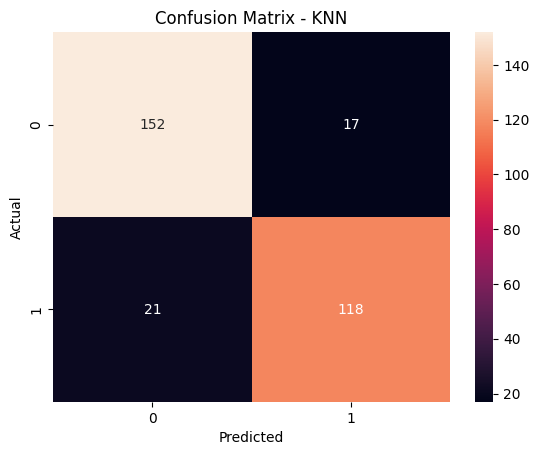

In [ ]:
# ================================
# 8. CONFUSION MATRIX
# ================================
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# ================================
# 9. CROSS VALIDATION (REALISTIC)
# ================================
print("\n================ CROSS VALIDATION ================\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")


================ CROSS VALIDATION ================

Logistic Regression: Mean Accuracy = 0.8828
Decision Tree: Mean Accuracy = 0.8291
Random Forest: Mean Accuracy = 0.8789
SVM: Mean Accuracy = 0.6865
KNN: Mean Accuracy = 0.6768


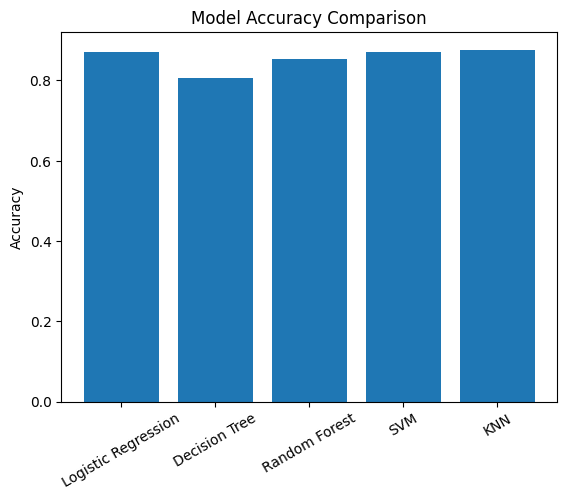

In [ ]:
# ================================
# 10. ACCURACY COMPARISON GRAPH
# ================================
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

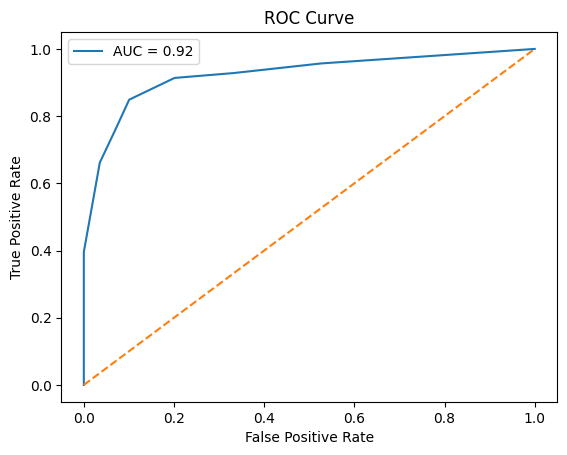

In [ ]:
from sklearn.metrics import roc_curve, auc

# Use best model
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

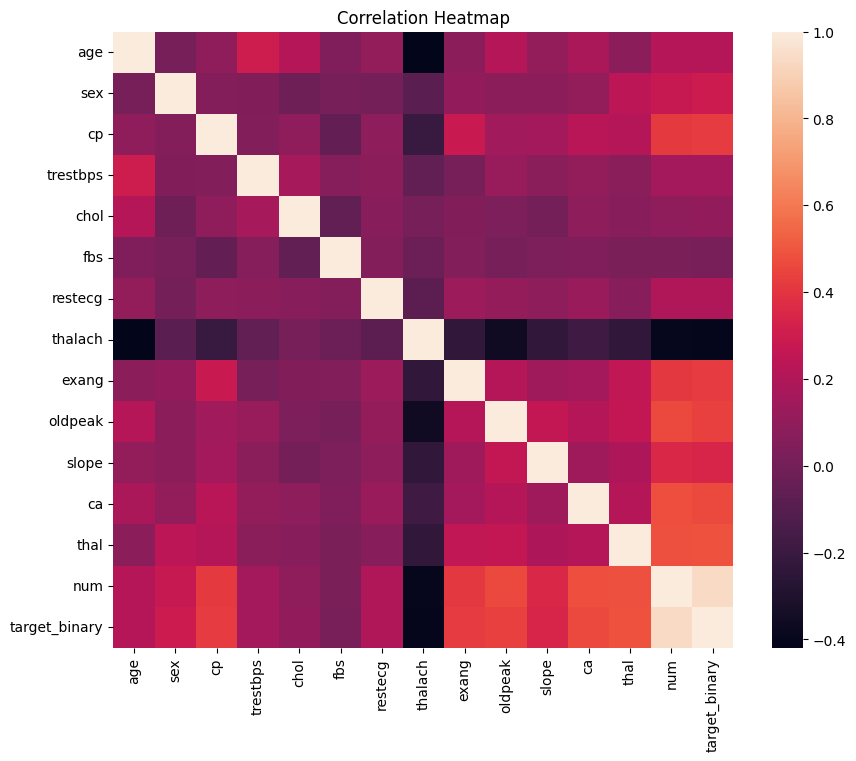

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8994413407821229
Test Accuracy: 0.8766233766233766


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = best_model.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.8740740740740741
Recall: 0.8489208633093526
F1 Score: 0.8613138686131386


In [ ]:
import joblib

joblib.dump(best_model, 'heart_model.pkl')
print("Model saved!")

Model saved!
